In [4]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path(__file__).parent / "data"
count_data = pd.read_csv(DATA_DIR / "txtdata.csv")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
from scipy.special import gammaln, logsumexp
from scipy.stats import gamma
from scipy.stats import gaussian_kde

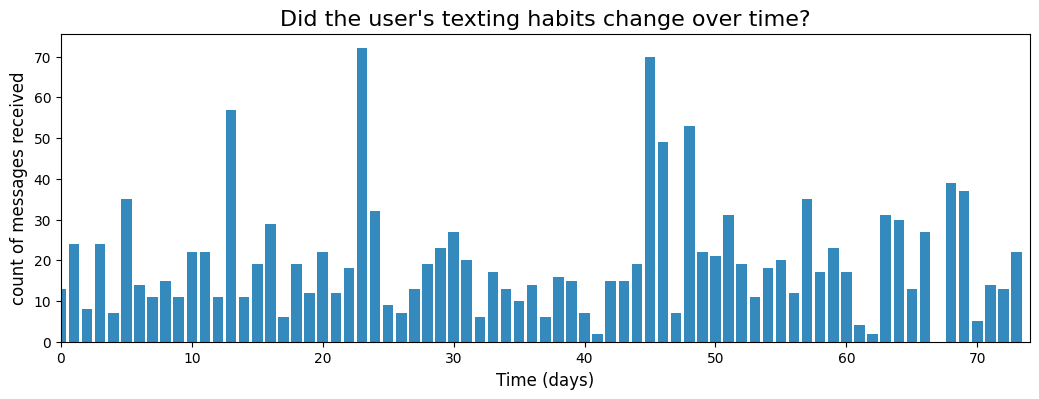

In [5]:
# CODE FROM BAYESIAN METHODS FOR HACKERS

plt.figure(figsize=(12.5, 4))
n_count_data = len(count_data)
plt.bar(np.arange(n_count_data), count_data, color="#348ABD")
plt.xlabel("Time (days)", fontsize=12)
plt.ylabel("count of messages received", fontsize=12)
plt.title("Did the user's texting habits change over time?", fontsize=16)
plt.xlim(0, n_count_data);

In [6]:
with pm.Model() as model:
    alpha = 1.0/count_data.mean()  # Recall count_data is the
                                   # variable that holds our txt counts
    lambda_1 = pm.Exponential("lambda_1", alpha)
    lambda_2 = pm.Exponential("lambda_2", alpha)

    tau = pm.DiscreteUniform("tau", lower=0, upper=n_count_data - 1)

In [7]:
with model:
    idx = np.arange(n_count_data) # Index
    lambda_ = pm.math.switch(tau > idx, lambda_1, lambda_2)

In [8]:
with model:
    observation = pm.Poisson("obs", lambda_, observed=count_data)

In [9]:
with model:
    step = pm.Metropolis()
    trace = pm.sample(10000, tune=5000, step=step, return_inferencedata=False)

Output()

In [10]:
lambda_1_samples = trace['lambda_1']
lambda_2_samples = trace['lambda_2']
tau_samples = trace['tau']

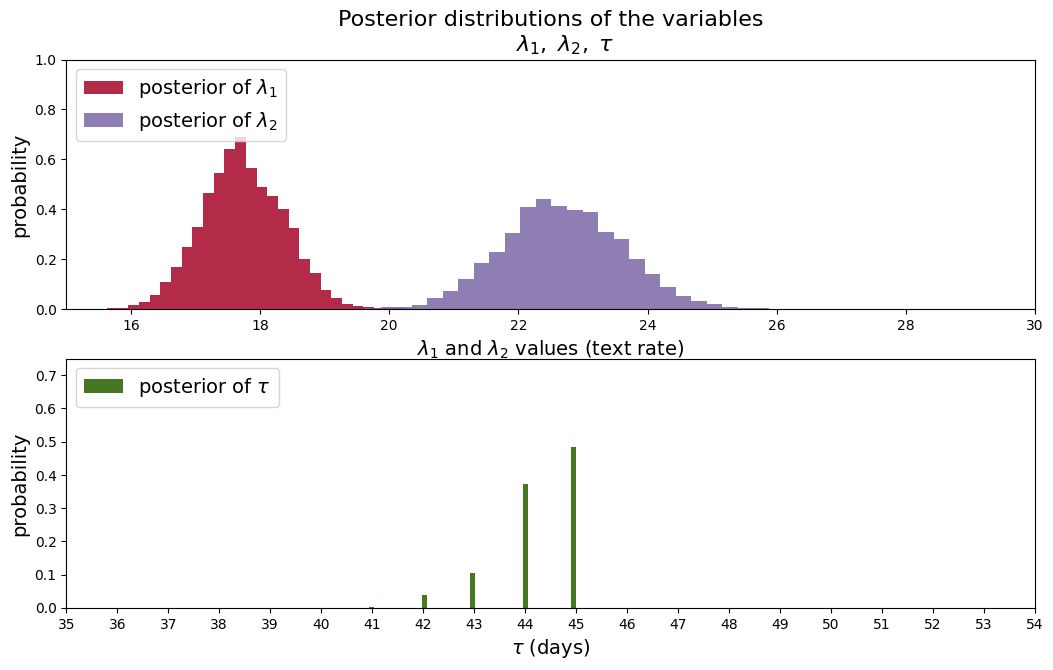

In [11]:
plt.figure(figsize=(12.5, 11))

ax = plt.subplot(311)
ax.set_autoscaley_on(False)

plt.hist(lambda_1_samples, histtype='stepfilled', bins=30, alpha=0.85,
         label=r"posterior of $\lambda_1$", color="#A60628", density=True)
plt.title(r"""Posterior distributions of the variables
    $\lambda_1,\;\lambda_2,\;\tau$""", fontsize=16)


ax.set_autoscaley_on(False)
plt.hist(lambda_2_samples, histtype='stepfilled', bins=30, alpha=0.85,
         label=r"posterior of $\lambda_2$", color="#7A68A6", density=True)
plt.legend(loc="upper left", fontsize=14)
plt.xlim([15, 30])
plt.xlabel(r"$\lambda_1$ and $\lambda_2$ values (text rate)", fontsize=14)
plt.ylabel("probability", fontsize=14)

plt.subplot(312)
w = 1.0 / tau_samples.shape[0] * np.ones_like(tau_samples)
plt.hist(tau_samples, bins=n_count_data, alpha=1,
         label=r"posterior of $\tau$",
         color="#467821", weights=w, rwidth=2.)
plt.xticks(np.arange(n_count_data))
plt.ylabel("probability", fontsize=14)

plt.legend(loc="upper left", fontsize=14)
plt.ylim([0, .75])
plt.xlim([35, len(count_data)-20])
plt.xlabel(r"$\tau$ (days)", fontsize=14)
plt.ylabel("probability", fontsize=14);

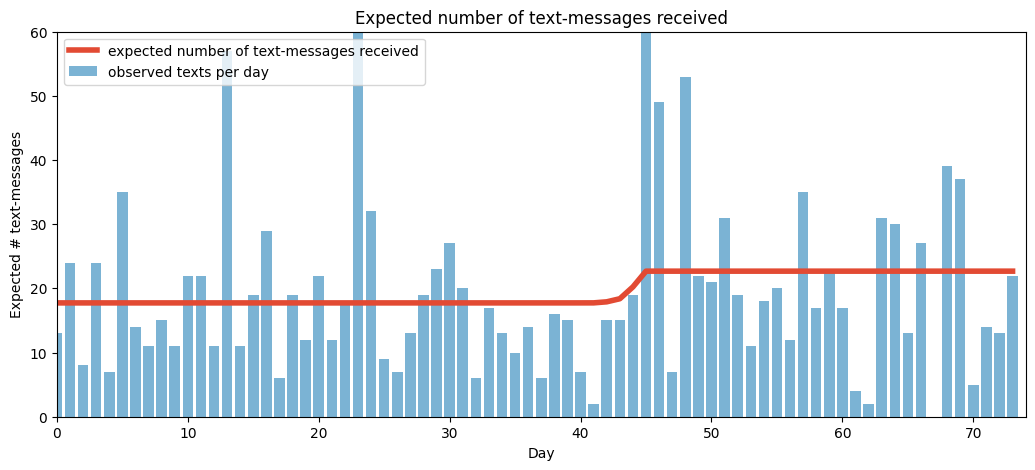

In [12]:
# CODE FROM BAYESIAN METHODS FOR HACKERS

plt.figure(figsize=(12.5, 5))
# tau_samples, lambda_1_samples, lambda_2_samples contain
# N samples from the corresponding posterior distribution
N = tau_samples.shape[0]
expected_texts_per_day = np.zeros(n_count_data)
for day in range(0, n_count_data):
    # ix is a bool index of all tau samples corresponding to
    # the switchpoint occurring prior to value of 'day'
    ix = day < tau_samples
    # Each posterior sample corresponds to a value for tau.
    # for each day, that value of tau indicates whether we're "before"
    # (in the lambda1 "regime") or
    #  "after" (in the lambda2 "regime") the switchpoint.
    # by taking the posterior sample of lambda1/2 accordingly, we can average
    # over all samples to get an expected value for lambda on that day.
    # As explained, the "message count" random variable is Poisson distributed,
    # and therefore lambda (the poisson parameter) is the expected value of
    # "message count".
    expected_texts_per_day[day] = (lambda_1_samples[ix].sum()
                                   + lambda_2_samples[~ix].sum()) / N


plt.plot(range(n_count_data), expected_texts_per_day, lw=4, color="#E24A33",
         label="expected number of text-messages received")
plt.xlim(0, n_count_data)
plt.xlabel("Day")
plt.ylabel("Expected # text-messages")
plt.title("Expected number of text-messages received")
plt.ylim(0, 60)
plt.bar(np.arange(len(count_data)), count_data, color="#348ABD", alpha=0.65,
        label="observed texts per day")

plt.legend(loc="upper left");

In [13]:
print("Lambda 1 posterior mean:", round(lambda_1_samples.mean(), 2))
print("Lambda 2 posterior mean:", round(lambda_2_samples.mean(),2))

Lambda 1 posterior mean: 17.74
Lambda 2 posterior mean: 22.68


In [14]:
percent_increase = (lambda_1_samples/lambda_2_samples).mean()
print("Mean expected percentage increase in texts:", round(100- percent_increase*100, 2),"%")

Mean expected percentage increase in texts: 21.68 %


# Analytical Approach

In [15]:
n = len(count_data)
alpha = 1.0 / count_data.mean()

# Exact posterior over tau
cumul = np.concatenate(([0.0], np.cumsum(count_data)))  # array of cumulative count data
total = cumul[-1]

k = np.arange(n)  # k = each possible value of tau
S1 = cumul[k]              # sum of counts before change point
S2 = total - S1          # sum of counts after change point
n1 = k                   # number of days in S1
n2 = n - k                # number of days in S2

log_term1 = np.log(alpha) + gammaln(S1 + 1) - (S1 + 1) * np.log(alpha + n1)
log_term2 = np.log(alpha) + gammaln(S2 + 1) - (S2 + 1) * np.log(alpha + n2)
log_post_tau_unnorm = log_term1 + log_term2

log_norm = logsumexp(log_post_tau_unnorm)
p_tau = np.exp(log_post_tau_unnorm - log_norm)  # P(tau = k | data)

# Marginal posteriors of the lambdas
shape1 = 1 + S1
rate1 = alpha + n1

shape2 = 1 + S2
rate2 = alpha + n2

lambda_grid = np.linspace(15, 30, 400)


def mixture_pdf(grid, shapes, rates, weights):
    dens = np.zeros_like(grid)
    for shp, rte, w in zip(shapes, rates, weights):
        if w > 0:
            dens += w * gamma.pdf(grid, a=shp, scale=1.0 / rte)
    return dens

lambda_1_density = mixture_pdf(lambda_grid, shape1, rate1, p_tau)
lambda_2_density = mixture_pdf(lambda_grid, shape2, rate2, p_tau)

# Posterior means (exact, closed form)
lambda_1_mean = np.sum(p_tau * shape1 / rate1)
lambda_2_mean = np.sum(p_tau * shape2 / rate2)
print("Lambda 1 posterior mean:", round(lambda_1_mean, 2))
print("Lambda 2 posterior mean:", round(lambda_2_mean, 2))

Lambda 1 posterior mean: 17.76
Lambda 2 posterior mean: 22.69


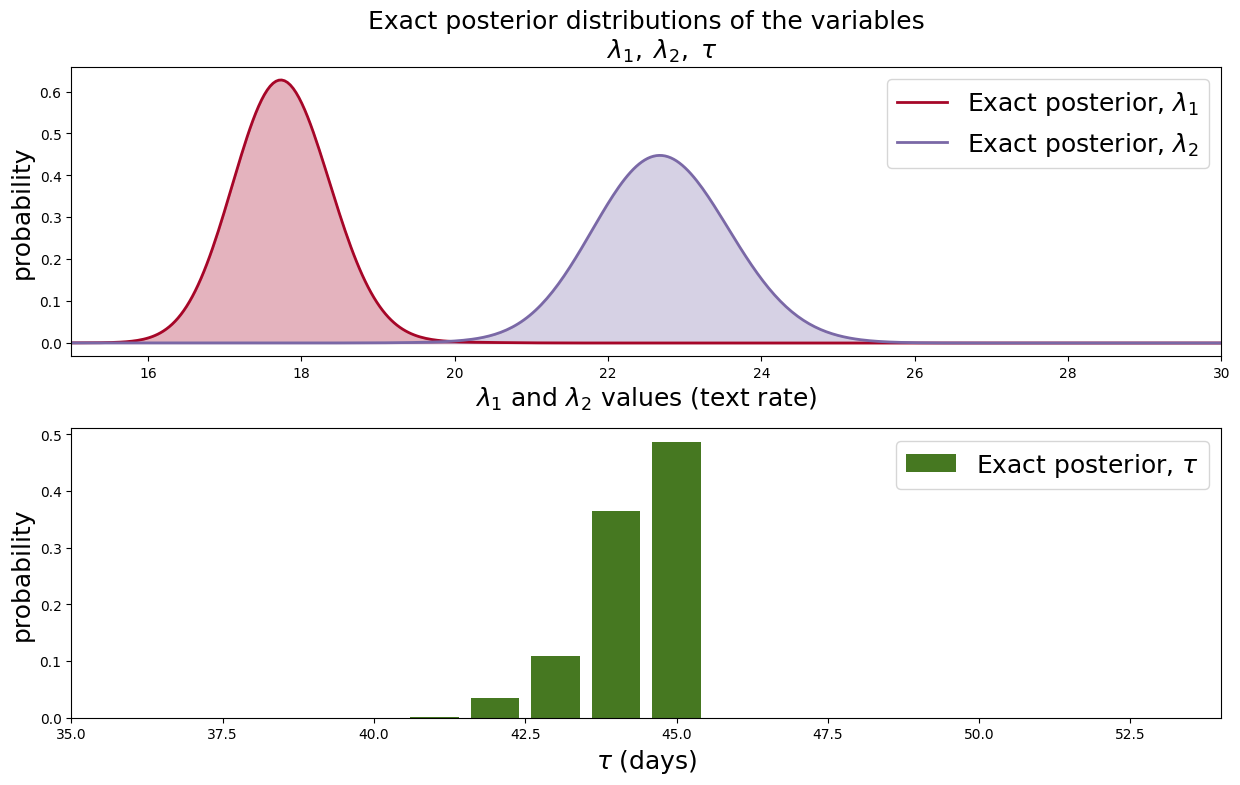

In [16]:
# PLOT

plt.figure(figsize=(12.5, 11))

ax = plt.subplot(311)
plt.plot(lambda_grid, lambda_1_density, color="#A60628", lw=2,
         label=r"Exact posterior, $\lambda_1$")
plt.fill_between(lambda_grid, lambda_1_density, color="#A60628", alpha=0.3)
plt.legend(loc="upper right", fontsize=18)
plt.title(r"""Exact posterior distributions of the variables
    $\lambda_1,\;\lambda_2,\;\tau$""", fontsize=18)
plt.xlim([15, 30])
plt.xlabel(r"$\lambda_1$ value (text rate)", fontsize=18)
plt.ylabel("density", fontsize=18)

plt.plot(lambda_grid, lambda_2_density, color="#7A68A6", lw=2,
         label=r"Exact posterior, $\lambda_2$")
plt.fill_between(lambda_grid, lambda_2_density, color="#7A68A6", alpha=0.3)
plt.legend(loc="upper right", fontsize=18)
plt.xlim([15, 30])
plt.xlabel(r"$\lambda_1$ and $\lambda_2$ values (text rate)", fontsize=18)
plt.ylabel("probability", fontsize=18)

plt.subplot(312)
plt.bar(k, p_tau, color="#467821", label=r"Exact posterior, $\tau$")
plt.legend(loc="upper right", fontsize=18)
plt.xlim([35, n - 20])
plt.xlabel(r"$\tau$ (days)", fontsize=18)
plt.ylabel("probability", fontsize=18)

plt.tight_layout()

In [17]:
from scipy.optimize import brentq

def mixture_cdf(x, shapes, rates, weights):
    return np.sum(weights * gamma.cdf(x, a=shapes, scale=1.0 / rates)) # gamma mixture at a single point of tau

def mixture_credible_interval(shapes, rates, weights, cred_mass=0.95, grid=lambda_grid):
    lo_q = (1 - cred_mass) / 2
    hi_q = 1 - lo_q
    lo = brentq(lambda x: mixture_cdf(x, shapes, rates, weights) - lo_q,
                grid.min(), grid.max())
    hi = brentq(lambda x: mixture_cdf(x, shapes, rates, weights) - hi_q,
                grid.min(), grid.max())
    return lo, hi

# 95% credible intervals
lambda_1_ci = mixture_credible_interval(shape1, rate1, p_tau)
lambda_2_ci = mixture_credible_interval(shape2, rate2, p_tau)

print("Lambda 1 posterior mean:", round(lambda_1_mean, 2))
print(f"Lambda 1 95% credible interval: ({lambda_1_ci[0]:.2f}, {lambda_1_ci[1]:.2f})")
print("Lambda 2 posterior mean:", round(lambda_2_mean, 2))
print(f"Lambda 2 95% credible interval: ({lambda_2_ci[0]:.2f}, {lambda_2_ci[1]:.2f})")

Lambda 1 posterior mean: 17.76
Lambda 1 95% credible interval: (16.52, 19.05)
Lambda 2 posterior mean: 22.69
Lambda 2 95% credible interval: (20.94, 24.48)


In [18]:
# 95% credible interval for tau
cdf_tau = np.cumsum(p_tau)

tau_lower = k[np.searchsorted(cdf_tau, 0.025)]
tau_upper = k[np.searchsorted(cdf_tau, 0.975)]
tau_mean = np.sum(k * p_tau)

print("Tau posterior mean:", round(tau_mean, 2))
print(f"Tau 95% credible interval: ({tau_lower}, {tau_upper})")


Tau posterior mean: 44.27
Tau 95% credible interval: (42, 45)


# Posterior Predictive Check

In [19]:
with model:
  ppc = pm.sample_posterior_predictive(trace)

Output()

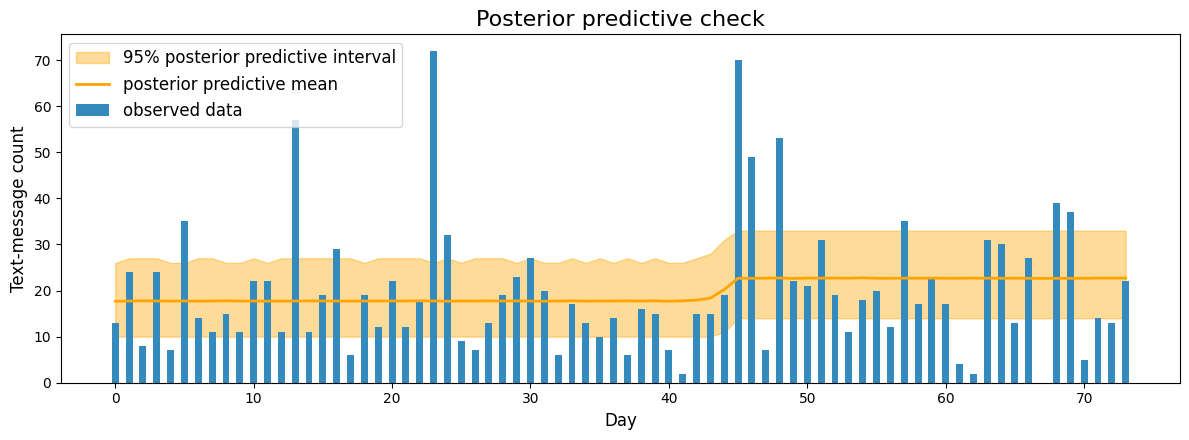

In [20]:
# Posterior predictive check

ppc_samples = ppc.posterior_predictive["obs"].values.reshape(-1, n_count_data)

ppc_mean = ppc_samples.mean(axis=0)
ppc_low, ppc_high = np.percentile(ppc_samples, [2.5, 97.5], axis=0)

plt.figure(figsize=(12, 4.5))
plt.fill_between(idx, ppc_low, ppc_high, color="orange", alpha=0.4,
                  label="95% posterior predictive interval")
plt.plot(idx, ppc_mean, color="orange", lw=2, label="posterior predictive mean")
plt.bar(idx, count_data, color="#348ABD", alpha=1, width=0.5, label="observed data")
plt.xlabel("Day", fontsize=12)
plt.ylabel("Text-message count", fontsize=12)
plt.title("Posterior predictive check", fontsize=16)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

In [21]:
# Fraction of observed days inside credible interval
coverage = np.mean((count_data >= ppc_low) & (count_data <= ppc_high))
print(f"Fraction of days within 95% posterior predictive interval: {coverage:.2f}")

Fraction of days within 95% posterior predictive interval: 0.61


In [22]:
n_count_data = len(count_data)
idx = np.arange(n_count_data)

# Sensitivity analysis: different values of prior hyperparameter alpha
alpha_base = 1.0 / count_data.mean()
alpha_multipliers = [0.2, 1.0, 5.0]
results = {}

for m in alpha_multipliers:
    a = alpha_base * m
    with pm.Model() as sens_model:
        lambda_1 = pm.Exponential("lambda_1", a)
        lambda_2 = pm.Exponential("lambda_2", a)
        tau = pm.DiscreteUniform("tau", lower=0, upper=n_count_data - 1)
        lambda_ = pm.math.switch(tau > idx, lambda_1, lambda_2)
        obs = pm.Poisson("obs", lambda_, observed=count_data)

        trace = pm.sample(5000, tune=2000, step=pm.Metropolis(), cores=1,
                           progressbar=False, return_inferencedata=True)

    results[m] = {
        "lambda_1": trace.posterior["lambda_1"].values.flatten(),
        "lambda_2": trace.posterior["lambda_2"].values.flatten(),
        "tau": trace.posterior["tau"].values.flatten(),
    }
    print(f"alpha x{m}: lambda_1 mean={results[m]['lambda_1'].mean():.2f}, "
          f"lambda_2 mean={results[m]['lambda_2'].mean():.2f}, "
          f"tau mean={results[m]['tau'].mean():.1f}")

/usr/local/lib/python3.13/dist-packages/pymc/step_methods/metropolis.py:319: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),


alpha x0.2: lambda_1 mean=17.75, lambda_2 mean=22.72, tau mean=44.3
alpha x1.0: lambda_1 mean=17.74, lambda_2 mean=22.72, tau mean=44.3
alpha x5.0: lambda_1 mean=17.67, lambda_2 mean=22.56, tau mean=44.3


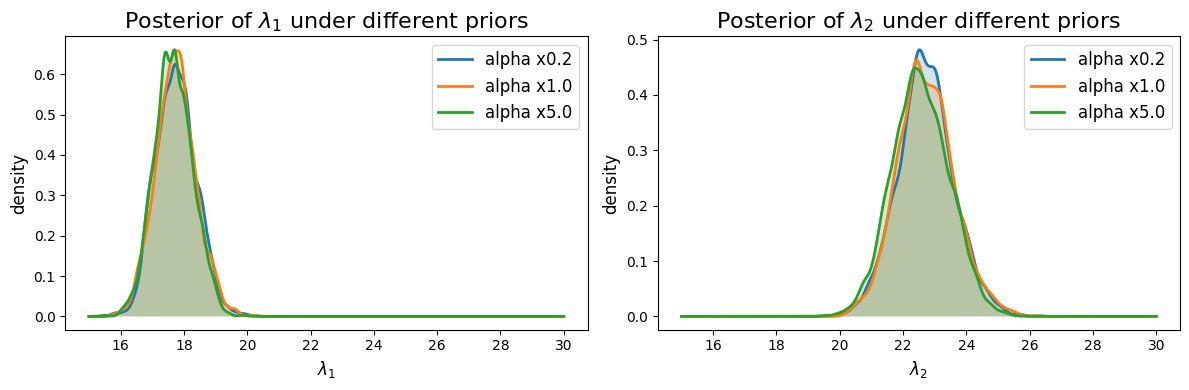

In [23]:
# Plot
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lambda_grid = np.linspace(15, 30, 400)

for m in alpha_multipliers:
    kde1 = gaussian_kde(results[m]["lambda_1"])
    kde2 = gaussian_kde(results[m]["lambda_2"])

    axes[0].plot(lambda_grid, kde1(lambda_grid), lw=2, label=f"alpha x{m}")
    axes[0].fill_between(lambda_grid, kde1(lambda_grid), alpha=0.2)

    axes[1].plot(lambda_grid, kde2(lambda_grid), lw=2, label=f"alpha x{m}")
    axes[1].fill_between(lambda_grid, kde2(lambda_grid), alpha=0.2)

axes[0].set_title(r"Posterior of $\lambda_1$ under different priors", fontsize=16)
axes[0].set_xlabel(r"$\lambda_1$", fontsize=12)
axes[0].set_ylabel("density", fontsize=12)
axes[0].legend(fontsize=12)

axes[1].set_title(r"Posterior of $\lambda_2$ under different priors", fontsize=16)
axes[1].set_xlabel(r"$\lambda_2$", fontsize=12)
axes[1].set_ylabel("density", fontsize=12)
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()